# Ejercicio propuesto

Utilizando el fichero CSV de jugadores de baloncesto que se te proporciona, realiza el siguiente estudio:
- Realiza los mismos pasos del vídeo anterior para limpiar filas nulas y traducir alturas y pesos. Elimina también los jugadores cuya posición no sea F, C o G.
- Muestra un gráfico circular con la proporción de jugadores en cada posición.
- Muestra un histograma con la distribución de las alturas y pinta en el gráfico de rojo la línea de la media y de verde la de la mediana.
- Selecciona una muestra de 10 jugadores que mantenga la proporción original de jugadores de cada tipo, aproximadamente.

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [129]:
df = pd.read_csv("players.csv", sep=',')
df.head()

,id,first_name,height_feet,height_inches,last_name,position,team,weight_pounds
0,14,Ike,NaN,NaN,Anigbogu,C,"{'id': 12, 'abbreviation': 'IND', 'city': 'Ind...",NaN
1,25,Ron,NaN,NaN,Baker,G,"{'id': 20, 'abbreviation': 'NYK', 'city': 'New...",NaN
2,47,Jabari,NaN,NaN,Bird,G,"{'id': 2, 'abbreviation': 'BOS', 'city': 'Bost...",NaN
3,67,MarShon,NaN,NaN,Brooks,G,"{'id': 15, 'abbreviation': 'MEM', 'city': 'Mem...",NaN
4,71,Lorenzo,NaN,NaN,Brown,G,"{'id': 28, 'abbreviation': 'TOR', 'city': 'Tor...",NaN


### Realiza los mismos pasos del vídeo anterior para limpiar filas nulas y traducir alturas y pesos.

In [130]:
# Eliminar filas que contengan valores nulos
df = df.dropna()

In [131]:
# Convertir unidades
df['height_cm'] = df['height_feet'] * 30.48
df['weight_kg'] = df['weight_pounds'] * 0.45

In [132]:
# Eliminar columnas
df = df.drop('id', axis=1)
df = df.drop('height_feet', axis=1)
df = df.drop('height_inches', axis=1)
df = df.drop('weight_pounds', axis=1)

### Elimina también los jugadores cuya posición no sea F, C o G.

In [133]:
posiciones_validas = ['F', 'C', 'G']
df = df[df['position'].isin(posiciones_validas)]
df

,first_name,last_name,position,team,height_cm,weight_kg
6,Alex,Abrines,G,"{'id': 21, 'abbreviation': 'OKC', 'city': 'Okl...",182.88,90.00
14,Kosta,Koufos,C,"{'id': 26, 'abbreviation': 'SAC', 'city': 'Sac...",213.36,110.25
2570,Michael,Beasley,F,"{'id': 25, 'abbreviation': 'POR', 'city': 'Por...",182.88,105.75
2572,Wade,Baldwin IV,G,"{'id': 11, 'abbreviation': 'HOU', 'city': 'Hou...",182.88,90.00
2573,Jared,Terrell,G,"{'id': 18, 'abbreviation': 'MIN', 'city': 'Min...",182.88,102.15
...,...,...,...,...,...,...
5017,Mitchell,Robinson,C,"{'id': 20, 'abbreviation': 'NYK', 'city': 'New...",213.36,108.00
5026,Collin,Sexton,G,"{'id': 29, 'abbreviation': 'UTA', 'city': 'Uta...",182.88,85.50
5027,Landry,Shamet,G,"{'id': 24, 'abbreviation': 'PHX', 'city': 'Pho...",182.88,84.60
5028,Anfernee,Simons,G,"{'id': 25, 'abbreviation': 'POR', 'city': 'Por...",182.88,83.25


### Muestra un gráfico circular con la proporción de jugadores en cada posición.

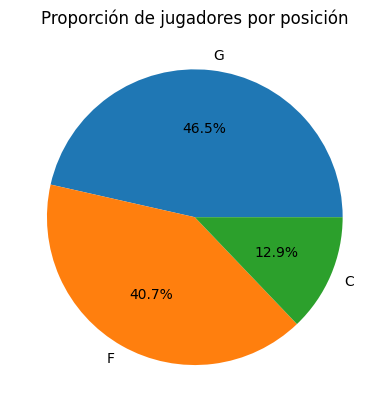

In [134]:
conteo_por_posicion = df['position'].value_counts()

plt.pie(
    conteo_por_posicion,
    labels=conteo_por_posicion.index,
    autopct='%1.1f%%'
)
plt.title('Proporción de jugadores por posición')
plt.show()

### Muestra un histograma con la distribución de las alturas y pinta en el gráfico de rojo la línea de la media y de verde la de la mediana.

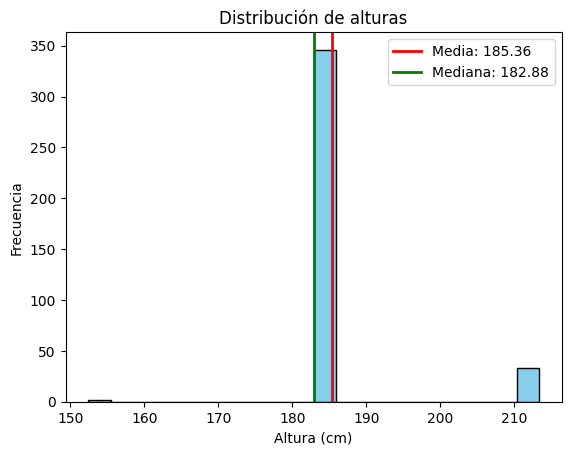

In [138]:
altura_media = df['height_cm'].mean()
altura_mediana = df['height_cm'].median()

plt.hist(df['height_cm'], bins=20, color= 'skyblue', edgecolor='black')
plt.axvline(altura_media, color='red', linewidth=2, label=f'Media: {altura_media:.2f}')
plt.axvline(altura_mediana, color='green', linewidth=2, label=f'Mediana: {altura_mediana:.2f}')
plt.title('Distribución de alturas')
plt.xlabel('Altura (cm)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

### Selecciona una muestra de 10 jugadores que mantenga la proporción original de jugadores de cada tipo, aproximadamente.

In [136]:
# Cantidad de jugadores por cada posición
conteo_por_posicion = df['position'].value_counts(normalize=True)
print(conteo_por_posicion)

position
G    0.464567
F    0.406824
C    0.128609
Name: proportion, dtype: float64


In [137]:
# DataFrame vacío para añadir muestra
muestra_estratificada = pd.DataFrame()

# Recorrer cada posición
for posicion, proporcion in conteo_por_posicion.items():
  n_muestra = round(proporcion * 10) # Número aproximado de jugadores
  muestra_posicion = df[df['position'] == posicion].sample(n=n_muestra, random_state=42)
  muestra_estratificada = pd.concat([muestra_estratificada, muestra_posicion])

# Reordenar filas aleatoriamente
muestra_estratificada = muestra_estratificada.sample(frac=1, random_state=42)

muestra_estratificada

,first_name,last_name,position,team,height_cm,weight_kg
2800,Patrick,Patterson,F,"{'id': 25, 'abbreviation': 'POR', 'city': 'Por...",182.88,103.50
3034,David,Nwaba,G,"{'id': 21, 'abbreviation': 'OKC', 'city': 'Okl...",182.88,98.55
3496,Justin,Jackson,F,"{'id': 2, 'abbreviation': 'BOS', 'city': 'Bost...",182.88,94.50
2637,Iman,Shumpert,G,"{'id': 3, 'abbreviation': 'BKN', 'city': 'Broo...",182.88,96.75
2841,Wes,Iwundu,F,"{'id': 1, 'abbreviation': 'ATL', 'city': 'Atla...",182.88,87.75
4530,Derrick,White,G,"{'id': 2, 'abbreviation': 'BOS', 'city': 'Bost...",182.88,85.50
3116,DeMarcus,Cousins,C,"{'id': 8, 'abbreviation': 'DEN', 'city': 'Denv...",182.88,121.50
3167,Jaylen,Adams,G,"{'id': 5, 'abbreviation': 'CHI', 'city': 'Chic...",182.88,85.50
2808,Jacob,Evans,G,"{'id': 18, 'abbreviation': 'MIN', 'city': 'Min...",182.88,94.50
4938,Marvin,Bagley III,F,"{'id': 9, 'abbreviation': 'DET', 'city': 'Detr...",182.88,105.30
